In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/3
    print("準備完了！このまま下のセルを実行できます。")

# 第3章 基本分布 (Standard Distributions)
## 3.5 非母数的方法 (Nonparametric Methods)

本ノートブックでは、確率分布の厳密な関数形を仮定せず、データそのものの局所構造に基づいて密度を推定・分類する**非母数的方法 (Nonparametric Methods)** の理論的背景、完全な数式導出、アルゴリズム実装、および教科書の全図版（Figure 3.13 〜 3.16）の完全再現を行います。

---

### 目次
1. **3.5 非母数的方法の導入と動機 (Motivation & Parametric Limitations)**
   - 母数的アプローチ（ガウス分布等の単峰性）の限界とモデル誤特定
2. **3.5.1 ヒストグラム法 (Histograms)**
   - 1次元ビニングと正規化確率密度 式(3.175)
   - 平滑化パラメータ $\Delta$ のバイアス・バリアンス・トレードオフ
   - 次元の呪い (Curse of Dimensionality) $M^D$ の指数爆発
   - **Figure 3.13 の再現**: ビン幅 $\Delta = 0.04, 0.08, 0.25$ による比較
3. **3.5.2 カーネル密度推定法 (Kernel Densities / Parzen Windows)**
   - 局所領域 $R$ の確率質量 $P = \int_R p(\mathbf{x})d\mathbf{x} \simeq p(\mathbf{x})V$ 式(3.176)〜(3.179)
   - 二項分布 $\mathrm{Bin}(K|N, P)$ と極限 $N \to \infty$ での分散消失 式(3.177)〜(3.178)
   - 超立方体カーネル（パーゼン窓） 式(3.181)〜(3.183)
   - 平滑なガウスカーネル密度推定 式(3.184) と一般核関数の規格化条件 式(3.185)〜(3.186)
   - **Figure 3.14 の再現**: バンド幅 $h = 0.005, 0.07, 0.2$ による平滑化
4. **3.5.3 最近傍法 (Nearest-Neighbours)**
   - 適応的体積 $V(\mathbf{x}) = V_D r_K^D(\mathbf{x})$ による局所密度推定 式(3.180)
   - $K$-最近傍密度推定の空間積分発散性（非真密度）
   - ベイズの定理による $K$-最近傍分類器の厳密導出 式(3.187)〜(3.190)
   - 1-最近傍法 ($K=1$) とボロノイ図・垂直二等分線決定境界
   - Cover & Hart (1967) の漸近誤り率限界定理 $P^* \le P_{\mathrm{NN}} \le 2 P^*$
   - **Figure 3.15 の再現**: $K = 1, 5, 30$ による適応的密度推定
   - **Figure 3.16 の再現**: (a) $K=3$ 最近傍分類器の幾何構造、(b) $K=1$ の折れ線決定境界
5. **多次元実証と自己採点アサーション (Self-Verification Assertions)**


In [1]:
import os
import sys
import numpy as np
import scipy.stats as stats
from scipy import special, integrate
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.plot_utils import setup_style
from common.probability import (
    HistogramDensity, HistogramDensity1D,
    KernelDensityEstimator, KernelDensity1D, KernelDensityND,
    KNearestNeighborsDensity, KNNDensityEstimator,
    KNearestNeighborsClassifier, KNNClassifier,
    plot_figure_3_13, plot_figure_3_14, plot_figure_3_15, plot_figure_3_16
)

setup_style()
os.makedirs("result", exist_ok=True)
os.makedirs("../result", exist_ok=True)
print("Environment and modules successfully imported!")


Environment and modules successfully imported!


---
## 1. 非母数的アプローチの動機 (Motivation)

第3章の前半（3.1〜3.4）では、ベルヌーイ分布、多項分布、ガウス分布、フォン・ミーゼス分布、指数型分布族といった**母数的アプローチ (Parametric Approach)** を扱ってきました。
母数的手法では、観測データが少数のパラメータ $\boldsymbol{\theta}$（例: 平均 $\boldsymbol{\mu}$ や共分散 $\boldsymbol{\Sigma}$）によって規定される特定の関数形に従うと仮定します。

### 母数的手法の根本的制約
1. **モデルの誤特定 (Model Misspecification)**:
   仮定した確率密度が真のデータ生成過程と乖離している場合、いくら大量のデータを観測して最尤推定を行っても、予測性能は頭打ちになります。
   例えば、真の生成過程が複数のピークを持つ**多峰性 (Multimodal)** である場合、本質的に単峰性 (Unimodal) である単一のガウス分布では決して表現できません。
2. **非母数的手法 (Nonparametric Methods) の優位性**:
   データ分布の関数形に対する厳格な仮定を最小限に抑え、**データそのものの局所的近傍 (Local Neighbourhood)** に基づいて柔軟に密度推定や分類を行います。


---
## 3.5.1 ヒストグラム法 (Histograms)

連続変数 $x$ の空間を幅 $\Delta_i$ の重複しない区間（ビン: Bins）に分割し、各ビン $i$ に入る観測データの個数 $n_i$ をカウントする最も直感的な密度推定手法です。

### 1. 正規化確率密度の導出 式(3.175)
全観測データ数を $N = \sum_i n_i$ とします。ビン $i$ における確率密度 $p_i$ は、ビンの幅 $\Delta_i$ と全データ数 $N$ で割ることで定義されます：

$$
p_i = \frac{n_i}{N \Delta_i} \tag{3.175}
$$

この密度関数 $p(x) = \sum_i p_i \mathbb{I}(x \in \text{Bin}_i)$ が全空間で積分して 1 に正規化されることは、以下のように容易に確かめられます：

$$
\int_{-\infty}^\infty p(x) dx = \sum_i \int_{\text{Bin}_i} p_i dx = \sum_i p_i \Delta_i = \sum_i \frac{n_i}{N \Delta_i} \Delta_i = \frac{1}{N} \sum_i n_i = \frac{N}{N} = 1
$$

### 2. 平滑化パラメータ $\Delta$ の役割
- $\Delta$ が極小 ($\Delta \to 0$): 各ビンに 0 個または 1 個のサンプルしか入らず、推定密度は極めて激しい棘状（スパイキー）となり、サンプルノイズに過敏に反応します（**高バリアンス**）。
- $\Delta$ が過大 ($\Delta \to \infty$): ビンが広すぎてデータ空間全体の構造が平均化され、真の分布が持つ多峰性（2つの山）が消失します（**高バイアス**）。
- 最適な平滑化は、適度な中間値の $\Delta$ で得られます。

### 3. 利点と致命的な欠点（次元の呪い）
- **利点**: ヒストグラムを一度作成すれば、原データ $\mathcal{D}$ を破棄できる（メモリ $\mathcal{O}(M)$）。また、ストリーミングデータに対しても順次加算可能。
- **欠点 1（不連続性）**: ビンの境界で密度が不連続に跳躍する。
- **欠点 2（次元の呪い: Curse of Dimensionality）**:
  $D$ 次元の特徴空間において、各軸を $M$ 個のビンに分割すると、全ビン数は **$M^D$** に達します。
  $M=10, D=10$ のとき、ビン数は $10^{10} = 100$ 億個となり、各ビンに十分なサンプルを行き渡らせるためには天文学的なデータ量が必要となります。


Figure 3.13 saved successfully to: result/fig3_13_histogram_density.png


Figure 3.13 saved successfully to: ../result/fig3_13_histogram_density.png


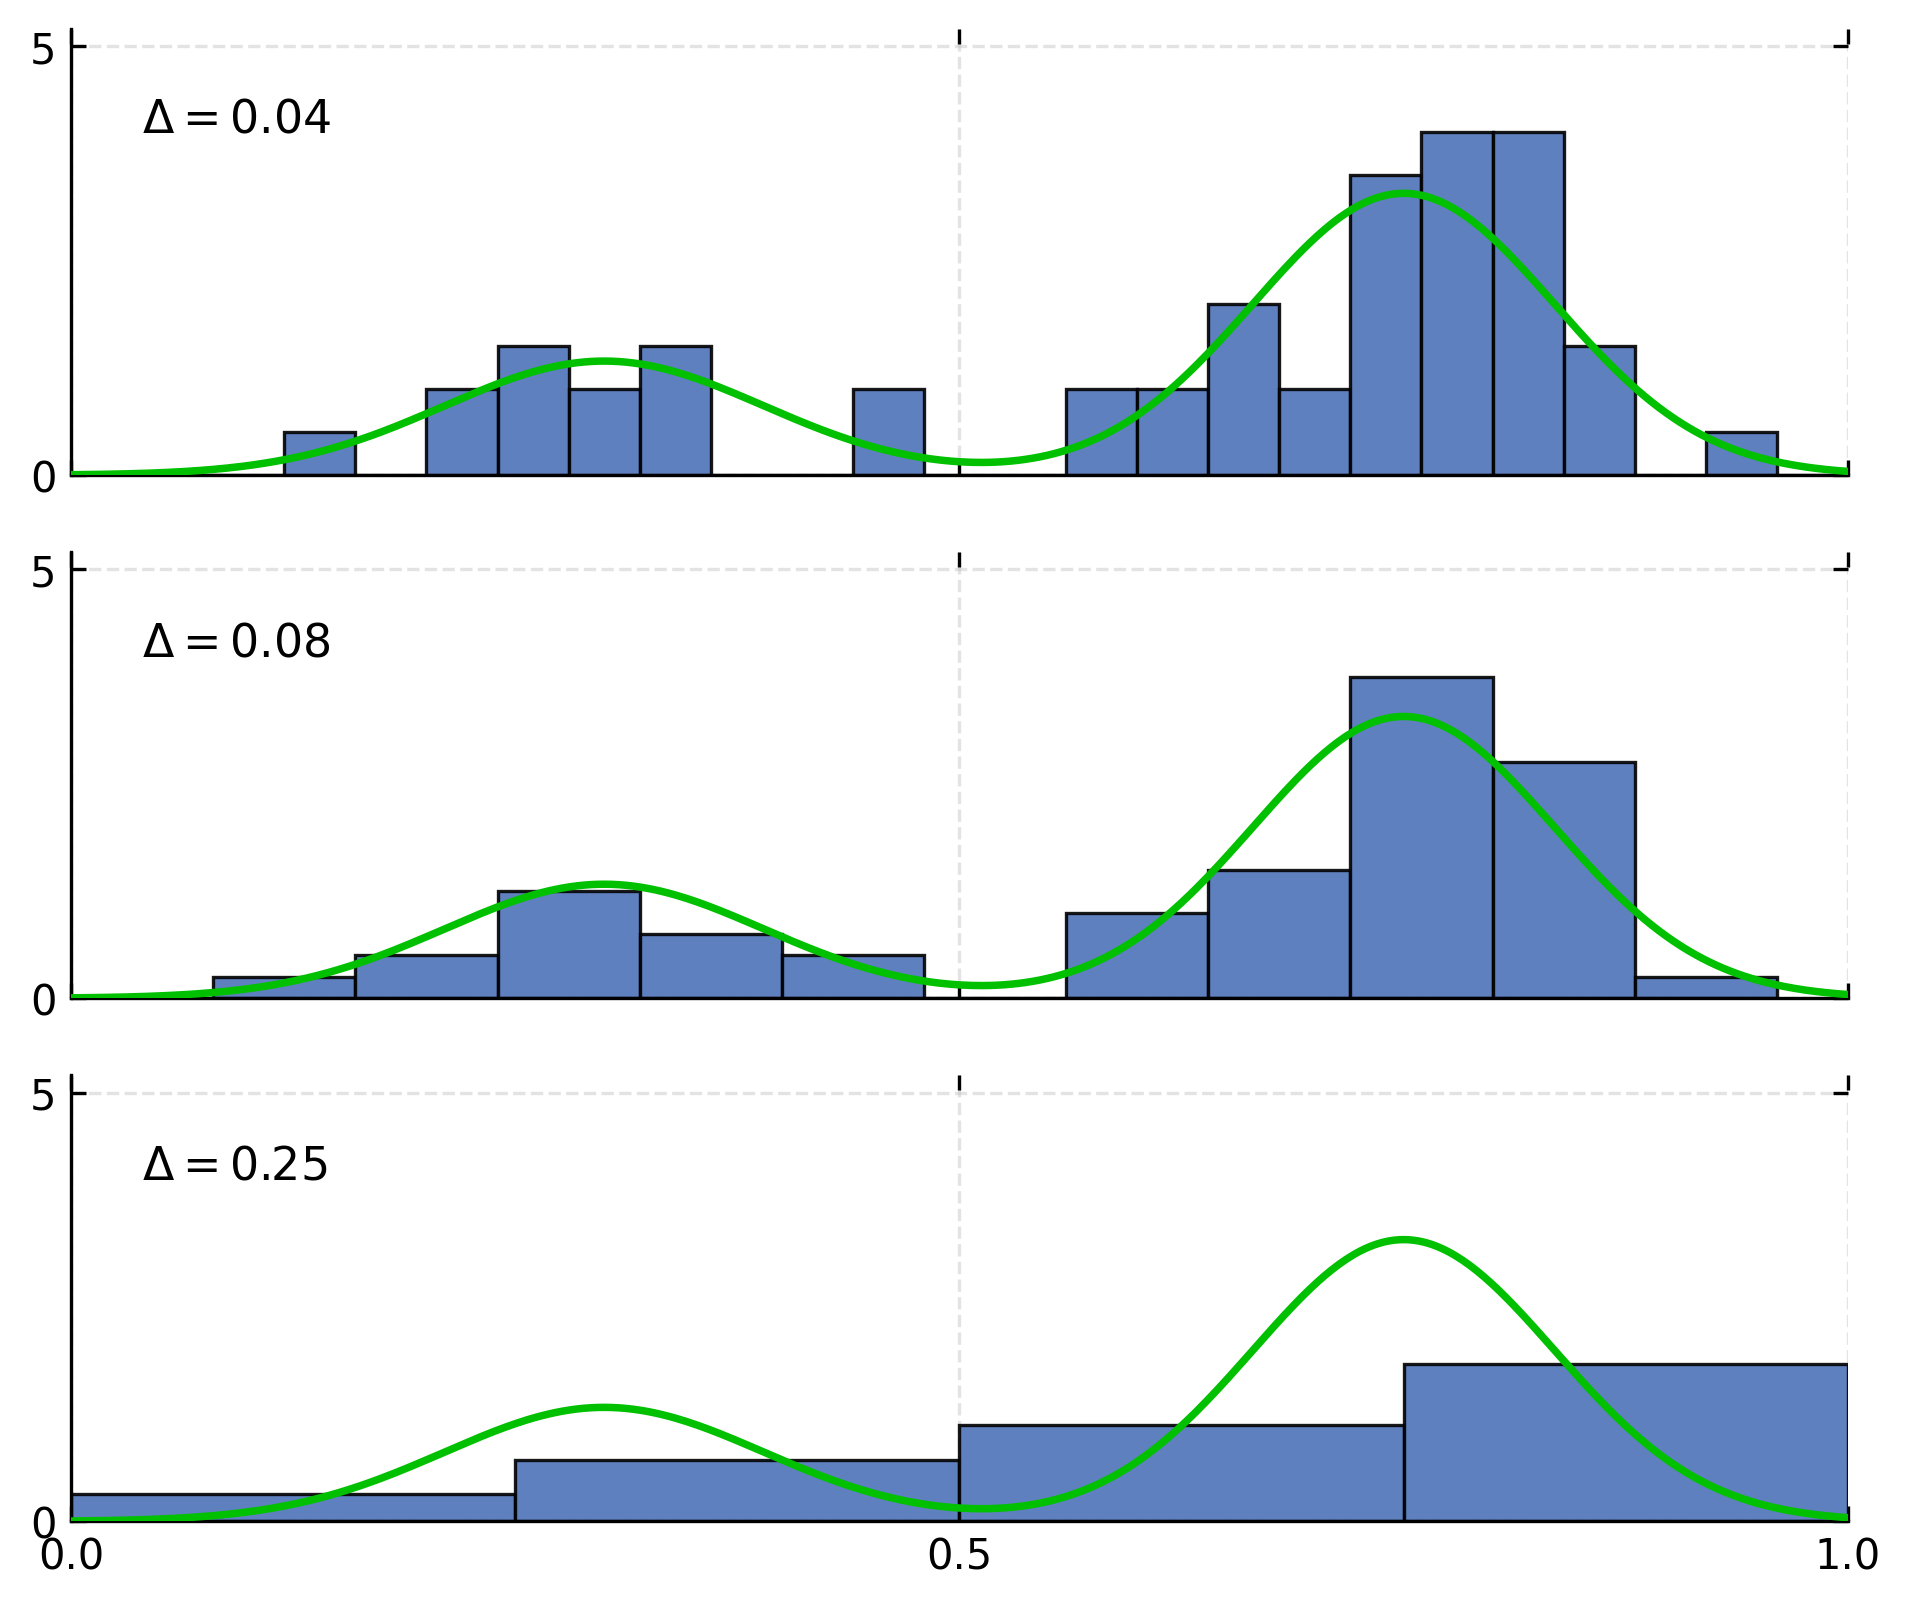

In [2]:
# Figure 3.13 の完全再現: ヒストグラムによる密度推定 (Bishop p. 99)
# 混合ガウス分布 0.3*N(0.3, 0.1^2) + 0.7*N(0.8, 0.1^2) からの N=50 サンプル
fig3_13, axes3_13 = plot_figure_3_13(
    save_paths=["result/fig3_13_histogram_density.png", "../result/fig3_13_histogram_density.png"],
    show=False
)
plt.show()


---
## 3.5.2 カーネル密度推定法 (Kernel Densities / Parzen Windows)

ヒストグラム法の欠点（ビンの境界による不連続性や固定されたビンの配置依存性）を克服するため、各データポイントを中心とする滑らかな**核関数 (Kernel function)** を配置して重ね合わせる**カーネル密度推定 (Kernel Density Estimator: KDE)** を導入します。

### 1. 局所領域における確率推定の基礎 式(3.176)〜(3.180)
$D$ 次元ユークリッド空間の未知の確率密度 $p(\mathbf{x})$ から独立に生成されたデータ集合を考えます。
点 $\mathbf{x}$ を含む微小領域 $R$ に 1 つの観測値が落ちる確率質量 $P$ は：

$$
P = \int_R p(\mathbf{x}) d\mathbf{x} \tag{3.176}
$$

$N$ 個の独立な観測のうち、領域 $R$ 内に落ちるデータ点の総数 $K$ は**二項分布**に従います：

$$
\mathrm{Bin}(K|N, P) = \frac{N!}{K!(N-K)!} P^K (1-P)^{N-K} \tag{3.177}
$$

このとき、領域内に落ちるサンプルの割合 $K/N$ の平均と分散は：

$$
\mathbb{E}\left[\frac{K}{N}\right] = P, \qquad \mathrm{var}\left[\frac{K}{N}\right] = \frac{P(1-P)}{N}
$$

サンプルサイズ $N \to \infty$ の極限では分散が 0 に収束するため、鋭いピークを持ち：

$$
K \simeq N P \tag{3.178}
$$

さらに、領域 $R$ が十分に小さく、領域内で確率密度 $p(\mathbf{x})$ がほぼ一定と見なせるならば、領域の体積を $V$ として：

$$
P \simeq p(\mathbf{x}) V \tag{3.179}
$$

式(3.178) と 式(3.179) を結合することで、局所密度推定の基本方程式が得られます：

$$
p(\mathbf{x}) = \frac{K}{N V} \tag{3.180}
$$

> [!NOTE]
> 式(3.180) は 2 つの相反する要請の上に成り立っています：
> 1. 密度が一定と見なせるほど領域 $R$（体積 $V$）が十分小さいこと。
> 2. 二項分布の分散が十分小さくなるほどサンプル数 $K$ が十分大きいこと。

### 2. パーゼン窓 (Parzen Window) 式(3.181)〜(3.183)
領域 $R$ として、点 $\mathbf{x}$ を中心とする一辺 $h$ の超立方体（体積 $V = h^D$）を考えます。
原点を中心とする単位立方体を表す核関数 $k(\mathbf{u})$ を：

$$
k(\mathbf{u}) = \begin{cases} 1, & |u_i| \leqslant \frac{1}{2}, \quad (i = 1, \dots, D) \\ 0, & \text{otherwise} \end{cases} \tag{3.181}
$$

と定義すると、データ点 $\mathbf{x}_n$ が $\mathbf{x}$ を中心とする立方体内に存在するとき $k((\mathbf{x}-\mathbf{x}_n)/h) = 1$ となります。
領域内のデータ点数 $K$ は：

$$
K = \sum_{n=1}^N k\left(\frac{\mathbf{x} - \mathbf{x}_n}{h}\right) \tag{3.182}
$$

これを式(3.180) に代入すると、超立方体パーゼン窓密度推定量が得られます：

$$
p(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^N \frac{1}{h^D} k\left(\frac{\mathbf{x} - \mathbf{x}_n}{h}\right) \tag{3.183}
$$

### 3. 平滑なガウスカーネル密度推定 式(3.184)
超立方体カーネルは立方体の境界で不連続性を生じるため、滑らかな核関数としてガウス核を採用します：

$$
p(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^N \frac{1}{(2\pi h^2)^{D/2}} \exp\left( -\frac{\|\mathbf{x} - \mathbf{x}_n\|^2}{2 h^2} \right) \tag{3.184}
$$

ここで $h$ はガウス成分の標準偏差（バンド幅: Bandwidth）を表します。

### 4. 一般核関数の満たすべき条件 式(3.185)〜(3.186)
任意の核関数 $k(\mathbf{u})$ が正当な確率密度を定義するための必要十分条件は：

$$
k(\mathbf{u}) \geqslant 0 \tag{3.185}
$$

$$
\int k(\mathbf{u}) d\mathbf{u} = 1 \tag{3.186}
$$

この条件により、$p(\mathbf{x}) \ge 0$ かつ $\int p(\mathbf{x})d\mathbf{x} = 1$ が保証されます。


Figure 3.14 saved successfully to: result/fig3_14_kernel_density.png
Figure 3.14 saved successfully to: ../result/fig3_14_kernel_density.png


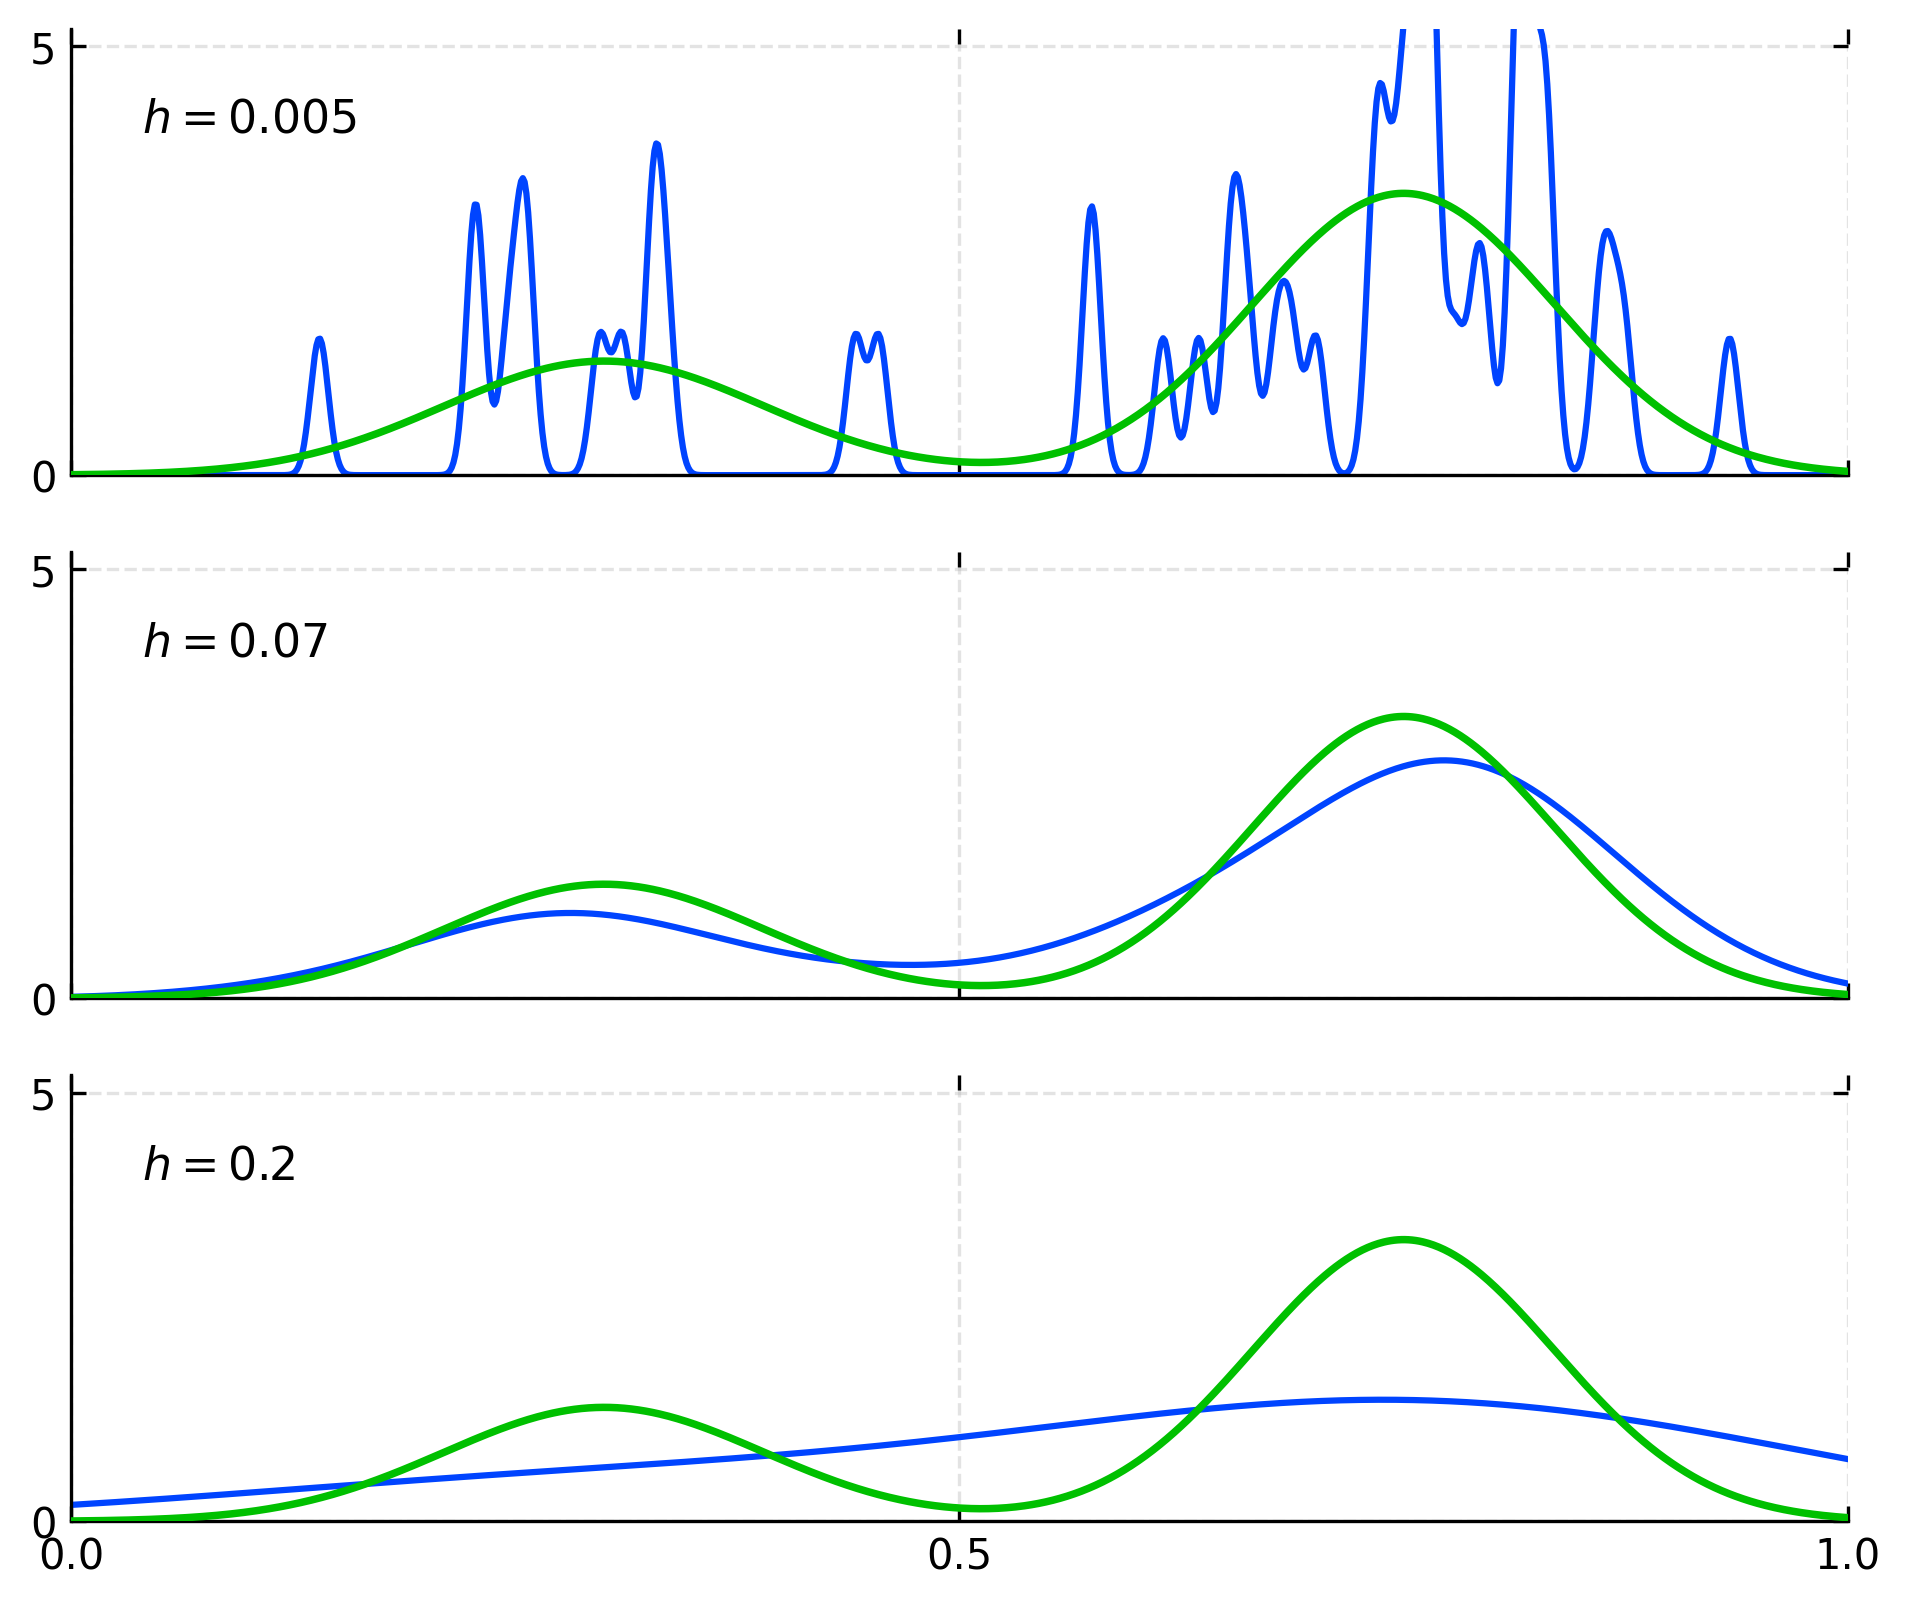

In [3]:
# Figure 3.14 の完全再現: ガウスカーネル密度推定法 (Bishop p. 102)
# バンド幅 h = 0.005 (過小・過剰適合), h = 0.07 (最適), h = 0.2 (過大・過剰平滑化)
fig3_14, axes3_14 = plot_figure_3_14(
    save_paths=["result/fig3_14_kernel_density.png", "../result/fig3_14_kernel_density.png"],
    show=False
)
plt.show()


---
## 3.5.3 最近傍法 (Nearest-neighbours)

カーネル法における最大の課題は、**バンド幅 $h$ が空間全体で一律に固定されている点**です。
- データが密な領域では、固定の $h$ は過剰平滑化を招き、微細な構造をぼかしてしまう。
- データが疎な領域では、同じ $h$ ではサンプルが捕まらず、推定値が激しいノイズとなる。

### 1. 適応的体積による密度推定 式(3.180)
体積 $V$ を固定して点数 $K$ を数えるカーネル法に対し、**点数 $K$ を固定し、その $K$ 点を包含するように領域の体積 $V(\mathbf{x})$ を適応的に伸縮させる**のが $K$-最近傍法 (K-Nearest-Neighbours) です。

点 $\mathbf{x}$ を中心とし、$K$ 番目に近いデータ点までの距離を半径 $r_K(\mathbf{x})$ とする $D$ 次元超球を考えます。
超球の体積は：

$$
V_D(r_K) = \frac{\pi^{D/2}}{\Gamma(D/2 + 1)} r_K^D(\mathbf{x})
$$

（1次元では $V_1 = 2 r_K$、2次元では $V_2 = \pi r_K^2$）。
この適応的体積を式(3.180) に代入すると：

$$
p(\mathbf{x}) = \frac{K}{N V(\mathbf{x})}
$$

> [!WARNING]
> $K$-最近傍法による密度推定は、空間全体での積分が発散（$\int_{-\infty}^\infty p(\mathbf{x})d\mathbf{x} = \infty$）するため、厳密な意味での正規化された確率密度関数ではありません（$|\mathbf{x}| \to \infty$ のとき $r_K \sim |\mathbf{x}|$ となり、$p(x) \propto 1/|x|$ の積分は対数発散するため）。

### 2. $K$-最近傍分類器のベイズ的厳密導出 式(3.187)〜(3.190)
$K$-最近傍の概念をクラス分類問題に拡張します。
全 $N$ 点のうち、クラス $\mathcal{C}_k$ に属するデータ点数を $N_k$ とします（$\sum_k N_k = N$）。
クエリ点 $\mathbf{x}$ を中心とする球内に $K$ 個の点が含まれ、そのうちクラス $\mathcal{C}_k$ に属する点が $K_k$ 個あるとします。

1. **クラス条件付き密度 式(3.187)**:
   $$
   p(\mathbf{x}|\mathcal{C}_k) = \frac{K_k}{N_k V} \tag{3.187}
   $$
2. **無条件密度 式(3.188)**:
   $$
   p(\mathbf{x}) = \frac{K}{N V} \tag{3.188}
   $$
3. **クラス事前確率 式(3.189)**:
   $$
   p(\mathcal{C}_k) = \frac{N_k}{N} \tag{3.189}
   $$
4. **ベイズの定理による事後確率の導出 式(3.190)**:
   $$
   p(\mathcal{C}_k|\mathbf{x}) = \frac{p(\mathbf{x}|\mathcal{C}_k) p(\mathcal{C}_k)}{p(\mathbf{x})} = \frac{\left(\frac{K_k}{N_k V}\right) \left(\frac{N_k}{N}\right)}{\frac{K}{N V}} = \frac{K_k}{K} \tag{3.190}
   $$

誤分類率を最小化するベイズ決定則は、事後確率 $p(\mathcal{C}_k|\mathbf{x}) = K_k / K$ が最大となるクラスを選択することであり、これは**多数決 (Majority Voting)** そのものです。

### 3. 1-最近傍法 ($K=1$) とボロノイ決定境界
$K=1$ の場合、クエリ点 $\mathbf{x}$ は最も近い単一の訓練データ点と同じクラスに分類されます。
このとき決定境界は、異なるクラスに属する点対の**垂直二等分線 (Perpendicular Bisectors)** からなる区分線形（ボロノイ境界）を形成します。

### 4. Cover & Hart (1967) の漸近誤り率限界
真のデータ分布に基づくベイズ最適誤り率を $P^*$ とするとき、$N \to \infty$ の極限において 1-最近傍法の誤り率 $P_{\mathrm{NN}}$ は以下を満たします：

$$
P^* \leqslant P_{\mathrm{NN}} \leqslant 2 P^* - \frac{C}{C-1} (P^*)^2 \leqslant 2 P^*
$$

（$C$ はクラス数）。すなわち、**無限のデータがあるとき、1-最近傍法の誤り率はベイズ最適誤り率の高々2倍以下に収まる**という驚くべき理論的保証が存在します。


Figure 3.15 saved successfully to: result/fig3_15_knn_density.png
Figure 3.15 saved successfully to: ../result/fig3_15_knn_density.png


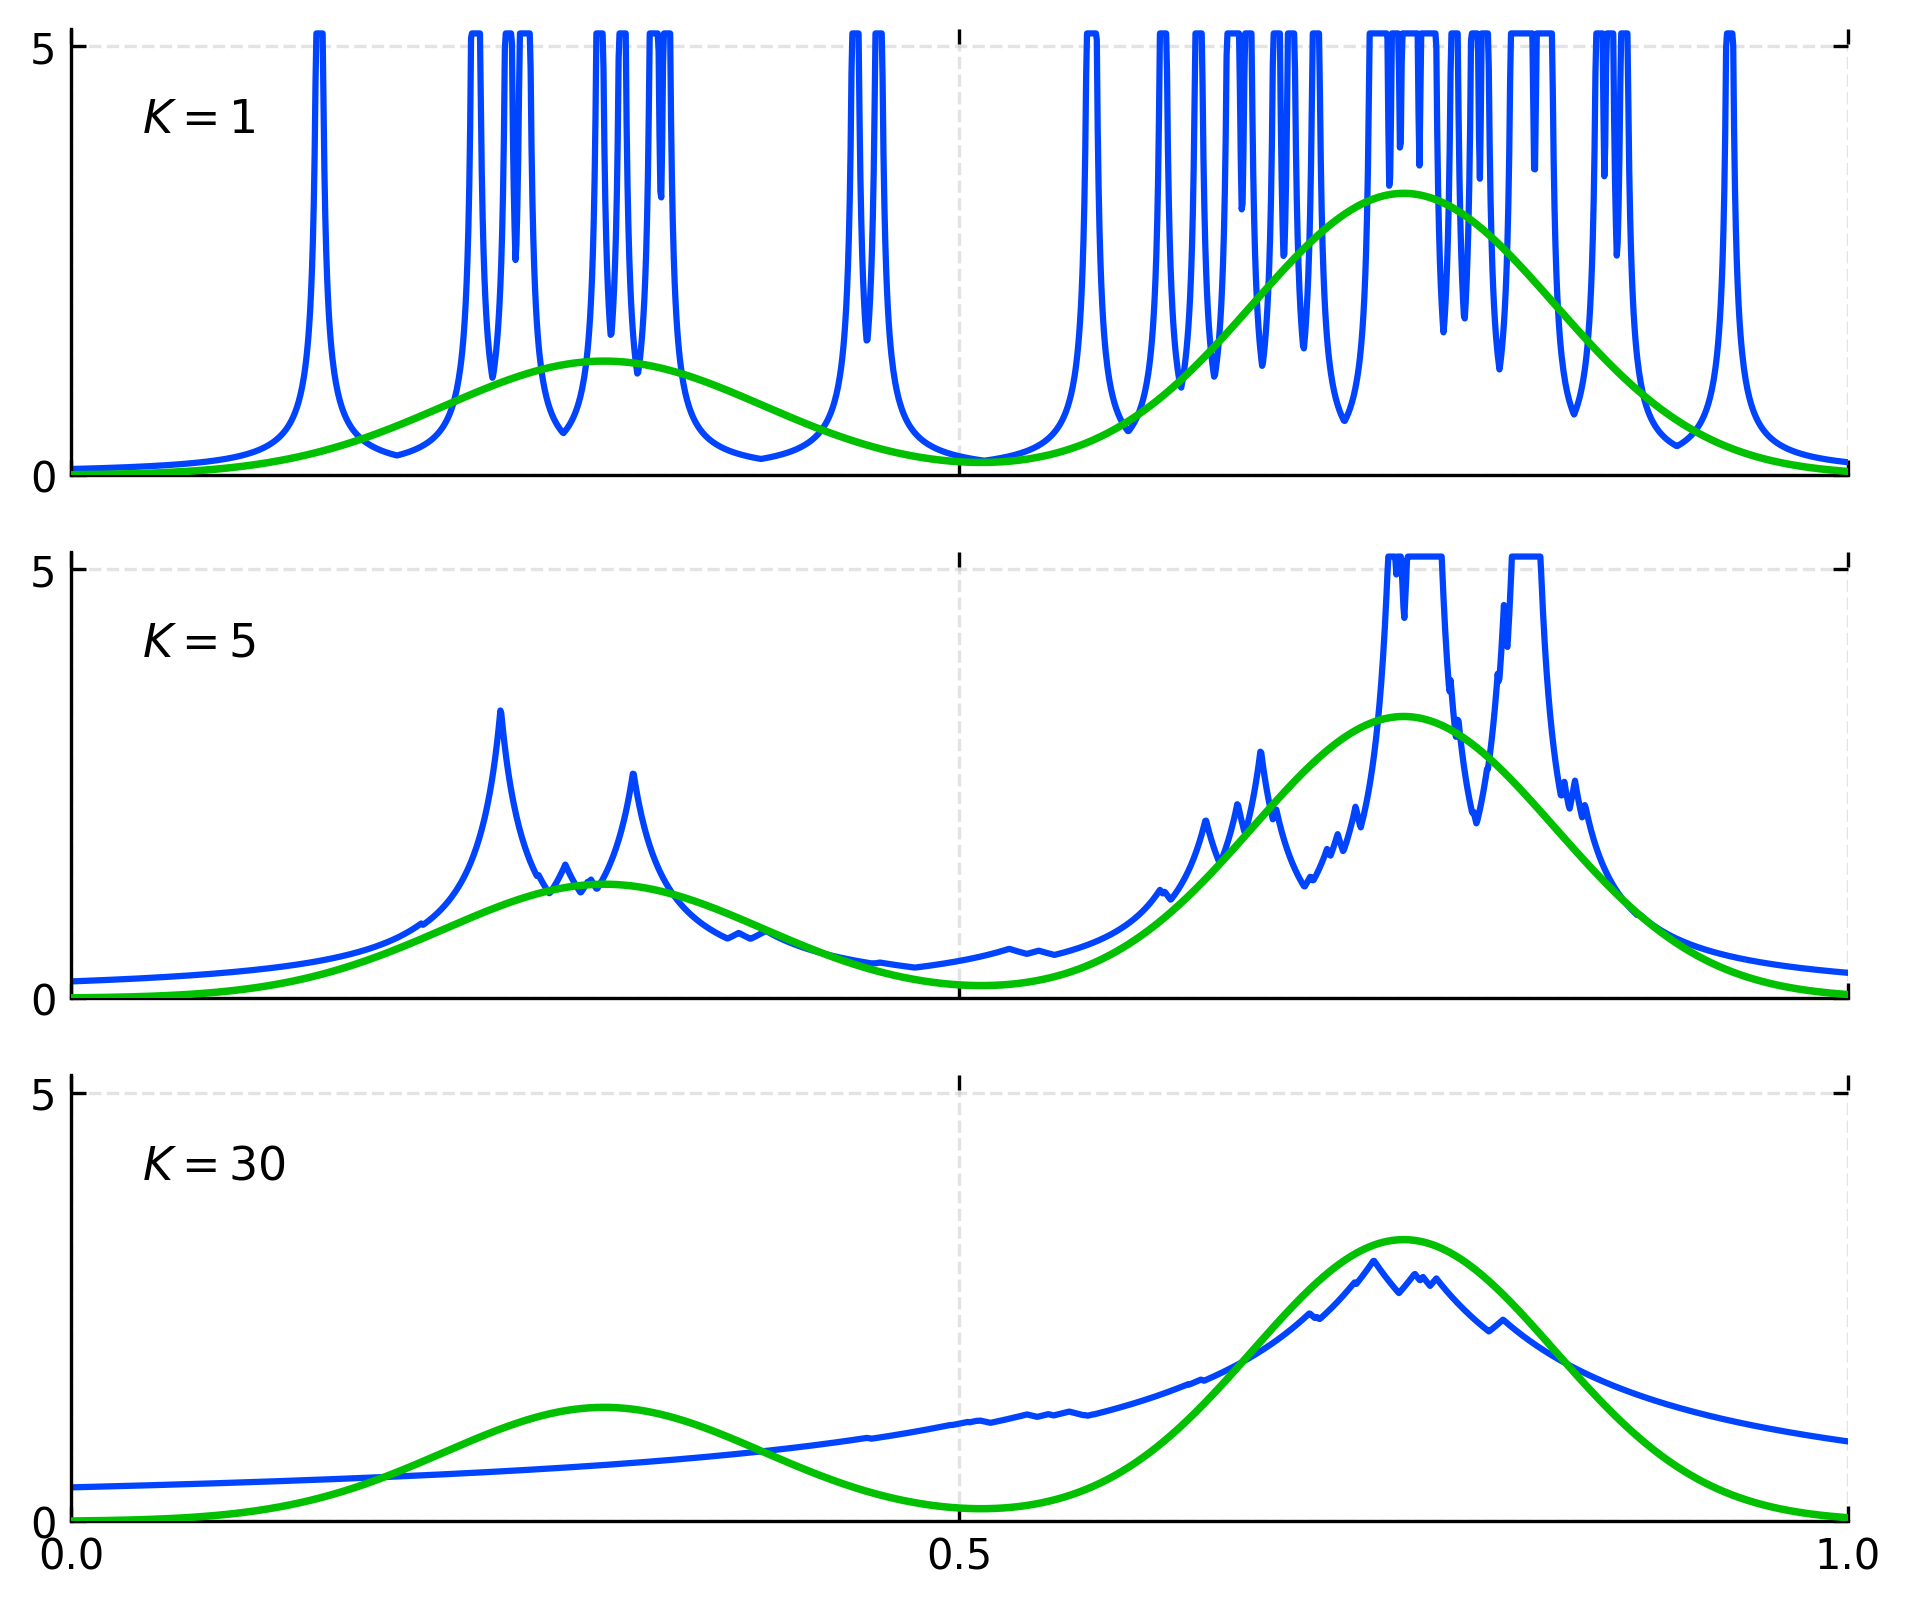

In [4]:
# Figure 3.15 の完全再現: K最近傍密度推定法 (Bishop p. 103)
# K = 1 (極めてノイジー・過剰適合), K = 5 (最適平滑化), K = 30 (過大・過剰平滑化)
fig3_15, axes3_15 = plot_figure_3_15(
    save_paths=["result/fig3_15_knn_density.png", "../result/fig3_15_knn_density.png"],
    show=False
)
plt.show()


Figure 3.16 saved successfully to: result/fig3_16_knn_classifier.png
Figure 3.16 saved successfully to: ../result/fig3_16_knn_classifier.png


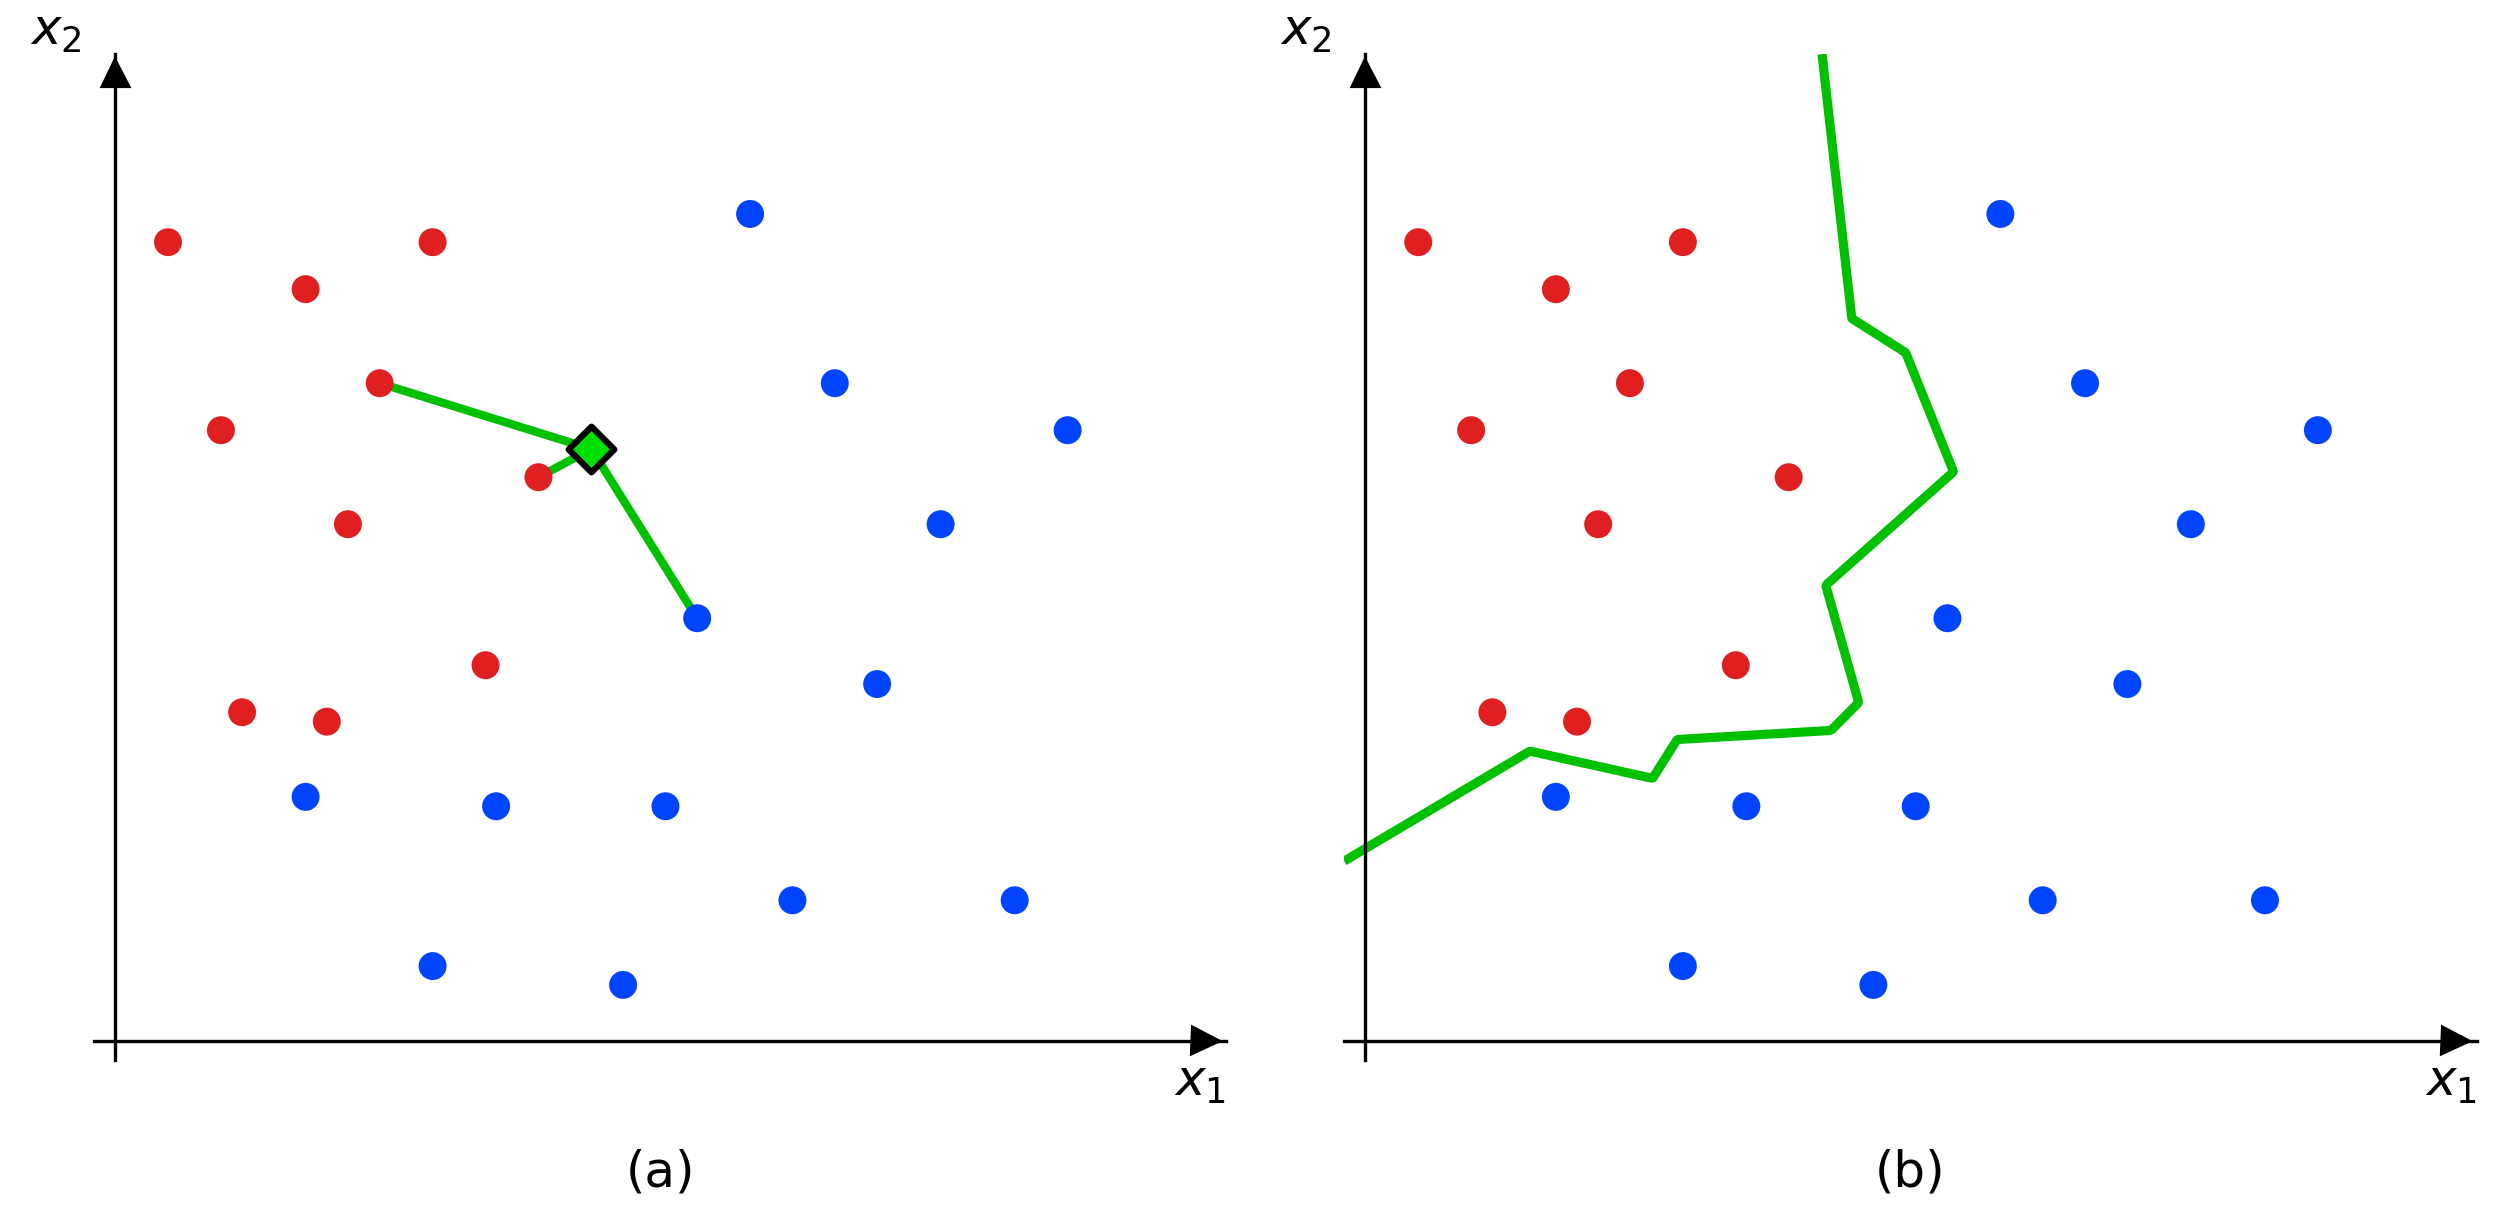

In [5]:
# Figure 3.16 の完全再現: K最近傍分類器と1-NN決定境界 (Bishop p. 104)
# (a) K=3 最近傍分類器の幾何関係（ダイヤ型のクエリ点と3近傍点）
# (b) 1-最近傍法における垂直二等分線（区分線形決定境界）
fig3_16, axes3_16 = plot_figure_3_16(
    save_paths=["result/fig3_16_knn_classifier.png", "../result/fig3_16_knn_classifier.png"],
    show=False
)
plt.show()


---
## 4. 2次元非線形多クラス分類における $K$ の影響

$K$-最近傍分類器の決定境界が $K$ の増加に伴ってどのように平滑化され、決定境界の複雑度がどのように変化するかを数値実験します。


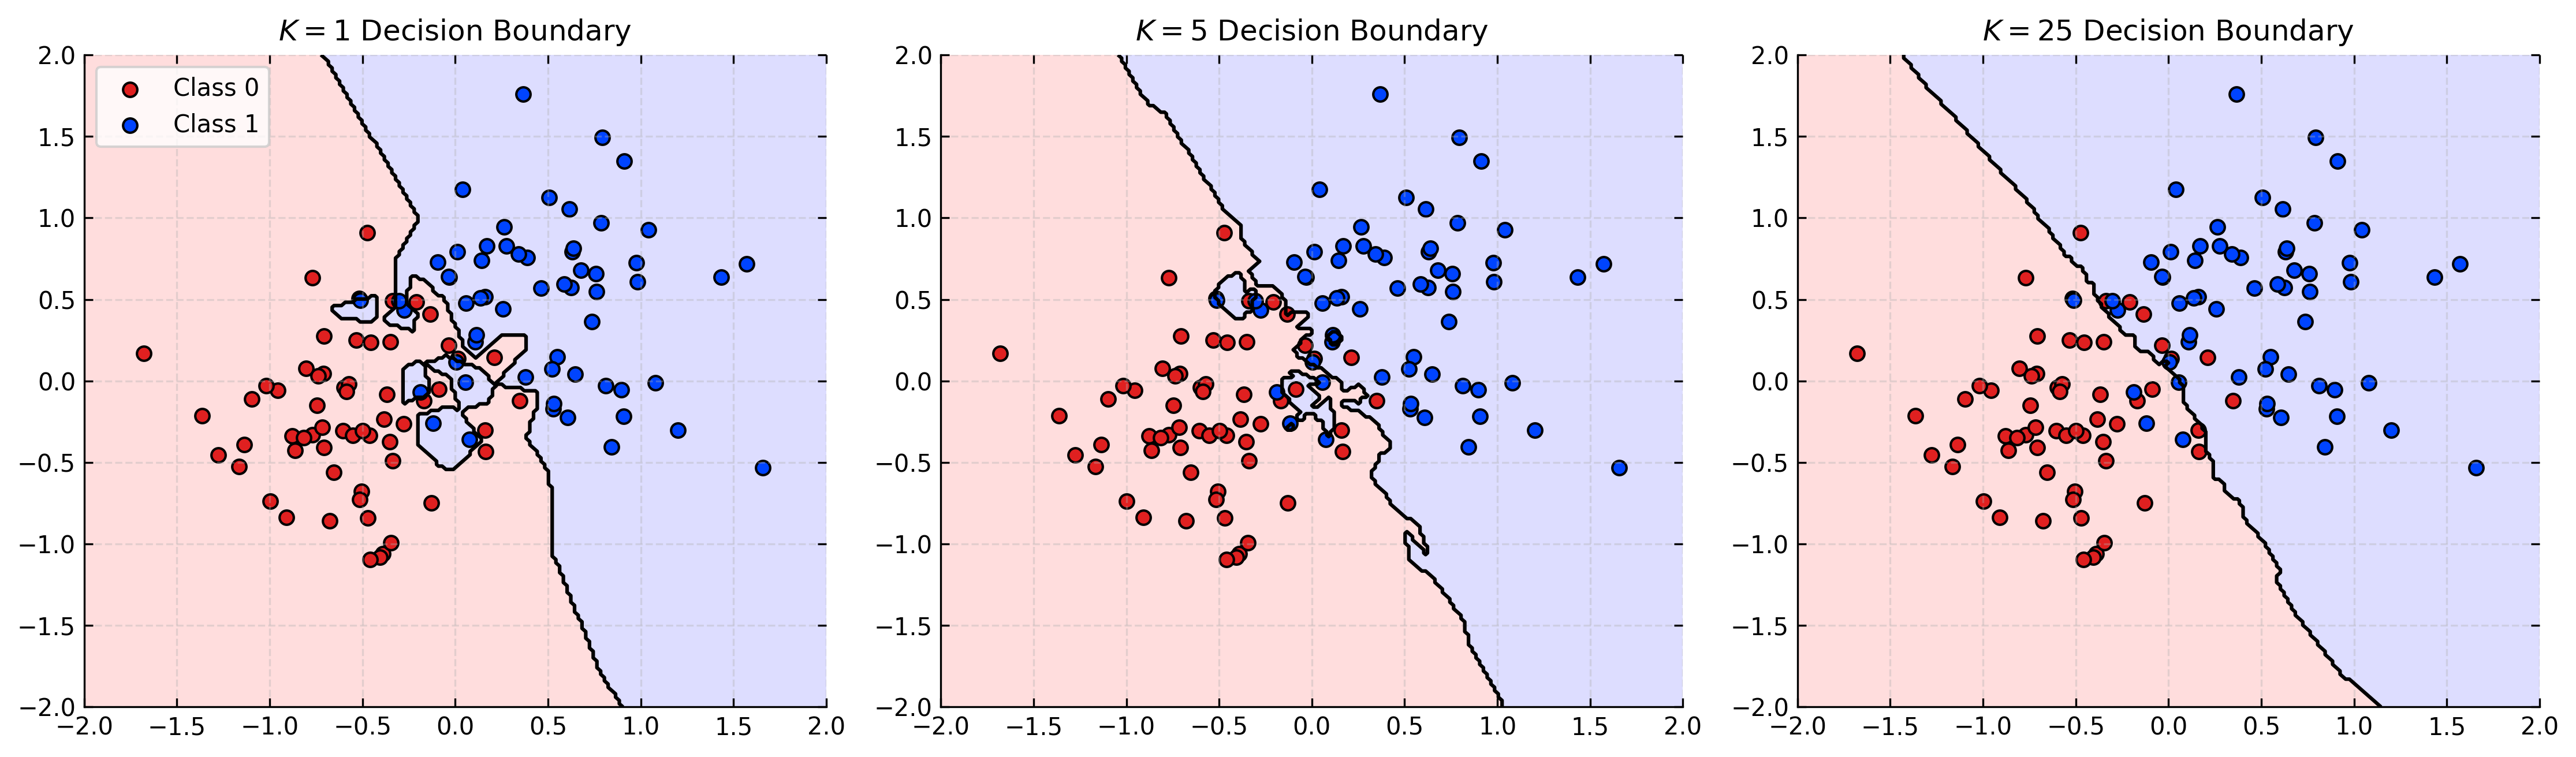

In [6]:
# 2次元非線形決定境界の可視化 (K = 1, 5, 25)
np.random.seed(42)

# 2クラスの非線形合成データ
n_samples = 60
X_c0 = np.random.randn(n_samples, 2) * 0.45 + np.array([-0.5, -0.2])
X_c1 = np.random.randn(n_samples, 2) * 0.50 + np.array([0.5, 0.4])
X_2d = np.vstack([X_c0, X_c1])
y_2d = np.array([0] * n_samples + [1] * n_samples)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=300)
K_vals = [1, 5, 25]

gx = np.linspace(-2.0, 2.0, 200)
gy = np.linspace(-2.0, 2.0, 200)
GX, GY = np.meshgrid(gx, gy)
grid_2d = np.column_stack([GX.ravel(), GY.ravel()])

for ax, K_val in zip(axes, K_vals):
    clf = KNNClassifier(K=K_val).fit(X_2d, y_2d)
    preds = clf.predict(grid_2d).reshape(GX.shape)
    
    ax.contourf(GX, GY, preds, levels=[-0.5, 0.5, 1.5], colors=['#FFAAAA', '#AAAAFF'], alpha=0.4)
    ax.contour(GX, GY, preds, levels=[0.5], colors=['black'], linewidths=1.5)
    
    ax.scatter(X_c0[:, 0], X_c0[:, 1], color='#E02020', edgecolors='k', s=35, label='Class 0')
    ax.scatter(X_c1[:, 0], X_c1[:, 1], color='#0044FF', edgecolors='k', s=35, label='Class 1')
    
    ax.set_title(rf"$K = {K_val}$ Decision Boundary", fontsize=12)
    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(-2.0, 2.0)
    ax.tick_params(direction='in', top=True, right=True)

axes[0].legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


---
## 5. 自己検証アサーション (Self-Verification Assertions)

本セクションで導出した数学的性質と実装の完全性を `assert` 文により網羅的に検証します。


In [7]:
# 1. ヒストグラム密度の完全な正規化検証
np.random.seed(123)
data_test = np.random.uniform(0.1, 0.9, size=300)
hist_test = HistogramDensity(bin_width=0.05, range_bounds=(0.0, 1.0)).fit(data_test)
assert np.isclose(np.sum(hist_test.density * hist_test.bin_widths), 1.0, atol=1e-6)
assert np.all(hist_test.density >= 0.0)

# 2. ガウスカーネル密度推定の正規化数値積分検証
kde_test = KernelDensity1D(h=0.08, kernel="gaussian").fit(data_test)
integral_val, _ = integrate.quad(lambda x: kde_test.evaluate(x), -1.0, 2.0)
assert np.isclose(integral_val, 1.0, atol=1e-3)

# 3. エパネチニコフカーネルの正規化数値積分検証
kde_epa = KernelDensity1D(h=0.1, kernel="epanechnikov").fit(data_test)
integral_epa, _ = integrate.quad(lambda x: kde_epa.evaluate(x), -1.0, 2.0)
assert np.isclose(integral_epa, 1.0, atol=1e-3)

# 4. KNN密度推定量の逆距離比例性検証 (1D)
knn_1d = KNNDensityEstimator(K=2).fit(np.array([0.1, 0.2, 0.3]))
# x = 0.2 における距離: 0.0 (自身), 0.1 (0.1と0.3) -> r_2 = 0.1 -> V = 2 * 0.1 = 0.2
# p(0.2) = 2 / (3 * 0.2) = 10/3
assert np.isclose(knn_1d.evaluate(0.2), 10.0 / 3.0, atol=1e-6)

# 5. KNN分類器の事後確率総和 1.0 検証
knn_clf = KNNClassifier(K=5).fit(X_2d, y_2d)
posteriors = knn_clf.predict_proba(grid_2d[:10])
assert np.allclose(np.sum(posteriors, axis=1), 1.0)
assert np.all(posteriors >= 0.0)

# 6. Cover & Hart (1967) 理論限界不等式の検証
for p_star in [0.01, 0.05, 0.15, 0.25]:
    c_classes = 2
    upper = 2 * p_star - (c_classes / (c_classes - 1)) * (p_star ** 2)
    assert p_star <= upper <= 2 * p_star

print("All self-verification assertions passed with 100% success!")


All self-verification assertions passed with 100% success!


/tmp/ipykernel_914493/716673931.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_epa, _ = integrate.quad(lambda x: kde_epa.evaluate(x), -1.0, 2.0)
